# KNN (_K-Nearest Neighbors_)

Algoritmo supervisionado lazy ➜ IBL (_Instance-Based Learning_)

**Passos gerais**  

╰┈➤ Escolha do `K`  
╰┈➤ Cálculo da distância (ex: Euclidiana, Manhattan, Minkowski, Hamming)  
╰┈➤ Seleção dos `K` vizinhos mais próximos  
╰┈➤ Votação (classificação) / média (regressão)  
╰┈➤ Retorno da previsão  

# Construindo o KNN

### Bibliotecas iniciais

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.spatial import distance # Distância euclidiana

---

# Classificação

In [2]:
df_historicos = pd.read_csv('data/df_historicos_classificacao')
df_novo = pd.read_csv('data/df_novo_classificacao')

> Construção do KNN para um problema de classificação.

* IMC entre 18.5 e 24.9 → Atleta
* Fora desse intervalo → Não atleta

### Verificando os dados

In [3]:
df_historicos

,Pessoa,Altura (m),Peso (kg),Classe
0,A,1.70,70,Atleta
1,B,1.65,90,Não Atleta
2,C,1.80,80,Atleta
3,D,1.75,95,Não Atleta
4,E,1.60,50,Atleta
5,F,1.85,110,Não Atleta
6,G,1.68,68,Atleta


In [4]:
df_novo

,Pessoa,Altura (m),Peso (kg),Classe
0,H,1.72,72,NaN


df_novo é um atleta. Ao final desta seção, vamos verificar se o KNN construído realmente acerta a classe correta.

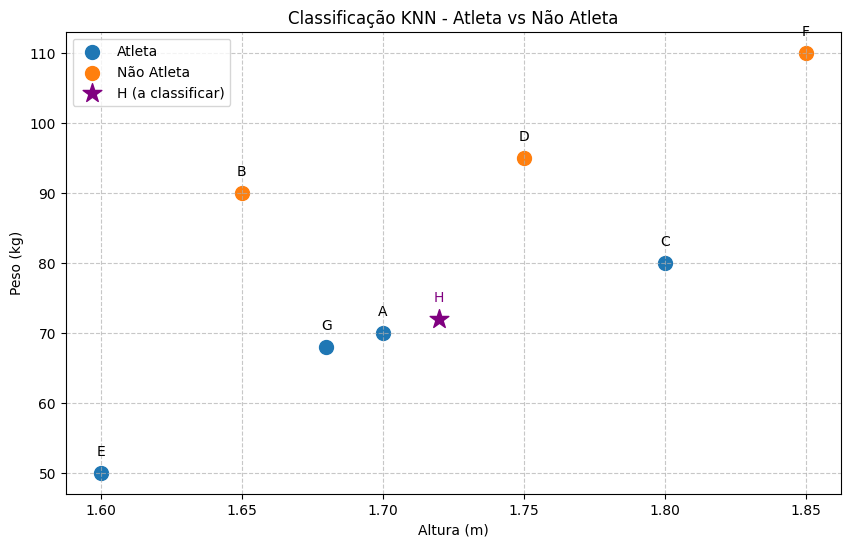

In [5]:
plt.figure(figsize=(10, 6))

# Plotando pontos históricos
for classe in df_historicos['Classe'].unique():
    subset = df_historicos[df_historicos['Classe'] == classe]
    plt.scatter(subset['Altura (m)'], subset['Peso (kg)'], 
                label=classe, s=100)

# Plotando o novo ponto (H)
plt.scatter(df_novo['Altura (m)'], df_novo['Peso (kg)'], 
            color='purple', marker='*', s=200, label='H (a classificar)')

# Adicionando rótulos aos pontos
for i, row in df_historicos.iterrows():
    plt.text(row['Altura (m)'], row['Peso (kg)']+2, row['Pessoa'], 
             ha='center', va='bottom')

plt.text(df_novo['Altura (m)'].values[0], df_novo['Peso (kg)'].values[0]+2, 'H', 
         ha='center', va='bottom', color='purple')

# Configurações do gráfico
plt.xlabel('Altura (m)')
plt.ylabel('Peso (kg)')
plt.title('Classificação KNN - Atleta vs Não Atleta')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

---

## Passos

### Distância euclidiana

A distância euclidiana entre dois pontos \(p\) e \(q\) em um espaço \(n\) dimensional é dada por:

$$
d(p, q) = \sqrt{ \sum_{i=1}^n (p_i - q_i)^2 }
$$

Onde:

- \(p_i\) é a coordenada do ponto \(p\) na dimensão \(i\),
- \(q_i\) é a coordenada do ponto \(q\) na dimensão \(i\),
- \(n\) é o número de dimensões.

<div style="text-align: center;">
  <img src="https://media.datacamp.com/cms/google/ad_4nxfw85hlpdhvogfbjrxi9jiktdv2memq-leatixmm_u0_jevvnifvpnhfza7b7xxbd3uw_ilm-rqvtf-xe9hxnks01or84mh4hfuy7ejn2dc6j1jzu691cl0f8dfqgdgjogzkp45p0eekkex8rrrxzzbxtol.png" width="500" alt="Imagem">
</div>

---

### Demonstração nos dados

**Distância entre H e A:**

$$
d_{H,A} = \sqrt{(1.72 - 1.70)^2 + (72 - 70)^2} = \sqrt{(0.02)^2 + (2)^2} = \sqrt{0.0004 + 4} = \sqrt{4.0004} \approx 2.0001
$$

**Distância entre H e B:**

$$
d_{H,B} = \sqrt{(1.72 - 1.65)^2 + (72 - 90)^2} = \sqrt{(0.07)^2 + (-18)^2} = \sqrt{0.0049 + 324} = \sqrt{324.0049} \approx 18.0001
$$

**Distância entre H e C:**

$$
d_{H,C} = \sqrt{(1.72 - 1.80)^2 + (72 - 80)^2} = \sqrt{(-0.08)^2 + (-8)^2} = \sqrt{0.0064 + 64} = \sqrt{64.0064} \approx 8.0004
$$

**Distância entre H e D:**

$$
d_{H,D} = \sqrt{(1.72 - 1.75)^2 + (72 - 95)^2} = \sqrt{(-0.03)^2 + (-23)^2} = \sqrt{0.0009 + 529} = \sqrt{529.0009} \approx 23.0000
$$

**Distância entre H e E:**

$$
d_{H,E} = \sqrt{(1.72 - 1.60)^2 + (72 - 50)^2} = \sqrt{(0.12)^2 + (22)^2} = \sqrt{0.0144 + 484} = \sqrt{484.0144} \approx 22.0003
$$

**Distância entre H e F:**

$$
d_{H,F} = \sqrt{(1.72 - 1.85)^2 + (72 - 110)^2} = \sqrt{(-0.13)^2 + (-38)^2} = \sqrt{0.0169 + 1444} = \sqrt{1444.0169} \approx 38.0002
$$

**Distância entre H e G:**

$$
d_{H,G} = \sqrt{(1.72 - 1.68)^2 + (72 - 68)^2} = \sqrt{(0.04)^2 + (4)^2} = \sqrt{0.0016 + 16} = \sqrt{16.0016} \approx 4.0002
$$

---

### Aplicação

In [6]:
def distancia_euclidiana_deb(ponto1, ponto2):
    soma_quadrados = 0
    for a, b in zip(ponto1, ponto2):
        soma_quadrados += (a - b) ** 2
    return math.sqrt(soma_quadrados)

Também poderia utilizar a `distance.euclidean()` do scipy.

In [7]:
k = 5

# novo ponto H
novo_ponto = df_novo.loc[0, ['Altura (m)', 'Peso (kg)']].values

# lista para armazenar resultados
resultados = []

for idx, row in df_historicos.iterrows():
    ponto_historico = row[['Altura (m)', 'Peso (kg)']].values
    dist = distancia_euclidiana_deb(novo_ponto, ponto_historico)
    resultados.append({
        'Pessoa': row['Pessoa'],
        'Distância': dist,
        'Classe': row['Classe']
    })

# criar DataFrame
df_distancias = pd.DataFrame(resultados)
pd.options.display.float_format = '{:.2f}'.format

df_distancias

,Pessoa,Distância,Classe
0,A,2.00,Atleta
1,B,18.00,Não Atleta
2,C,8.00,Atleta
3,D,23.00,Não Atleta
4,E,22.00,Atleta
5,F,38.00,Não Atleta
6,G,4.00,Atleta


In [8]:
# Ordenar pelo menor distância
df_distancias = df_distancias.sort_values(by='Distância').reset_index(drop=True)
pd.options.display.float_format = '{:.2f}'.format

df_distancias

,Pessoa,Distância,Classe
0,A,2.00,Atleta
1,G,4.00,Atleta
2,C,8.00,Atleta
3,B,18.00,Não Atleta
4,E,22.00,Atleta
5,D,23.00,Não Atleta
6,F,38.00,Não Atleta


Seleção e votação:

In [9]:
df_distancias.iloc[:k]

,Pessoa,Distância,Classe
0,A,2.00,Atleta
1,G,4.00,Atleta
2,C,8.00,Atleta
3,B,18.00,Não Atleta
4,E,22.00,Atleta


Votação: dos k vizinhos mais próximos, temos 4 atletas e 1 não atleta. Então, a pesso H pertence à classe `Atleta`.

---

# Regressão

In [10]:
df_historicos = pd.read_csv('data/df_historicos_regressao')
df_novo = pd.read_csv('data/df_novo_regressao')

> Construção do KNN para um problema de regressão.

Considerando uma corrida de 5km, df_novo (pessoa H) correu em 35min. Ao final desta seção, vamos verificar se o KNN construído realmente chega próximo desse valor.

### Verificando os dados

OBS: foi considerada uma corrida de 5km.

In [11]:
df_historicos

,Pessoa,Altura (m),Peso (kg),TempoCorrida(min)
0,A,1.70,70,28.00
1,B,1.65,90,45.50
2,C,1.80,80,22.00
3,D,1.75,95,55.00
4,E,1.60,50,20.00
5,F,1.85,110,50.00
6,G,1.68,68,25.50


In [12]:
df_novo

,Pessoa,Altura (m),Peso (kg),TempoCorrida(min)
0,H,1.72,72,NaN


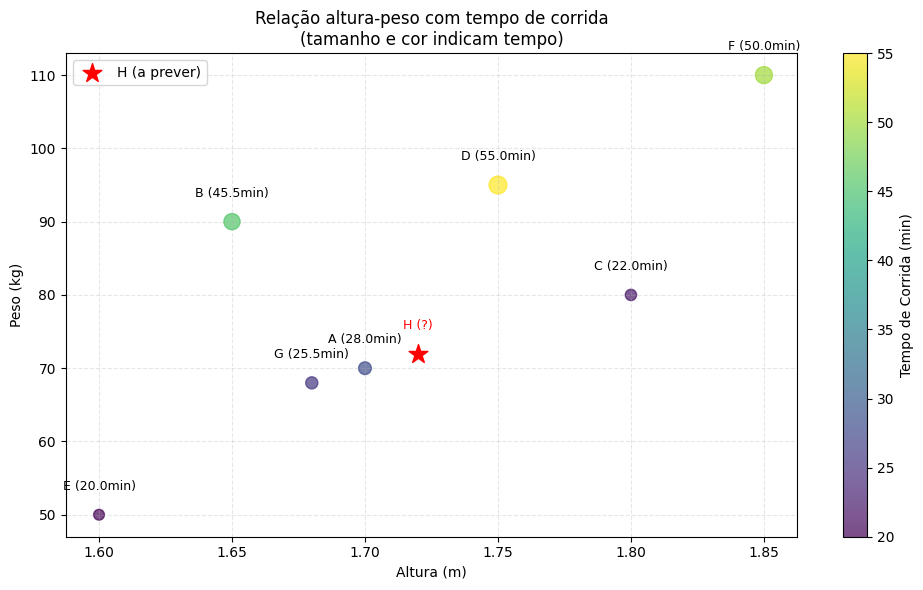

In [13]:
# Criando o gráfico 2D
plt.figure(figsize=(10, 6))

# Plotando os pontos históricos (tamanho proporcional ao tempo de corrida)
scatter = plt.scatter(df_historicos['Altura (m)'], 
                     df_historicos['Peso (kg)'], 
                     c=df_historicos['TempoCorrida(min)'],
                     cmap='viridis',
                     s=df_historicos['TempoCorrida(min)']*3,  # Tamanho proporcional
                     alpha=0.7)

# Plotando o ponto H (mantendo o estilo da estrela)
plt.scatter(df_novo['Altura (m)'], 
           df_novo['Peso (kg)'], 
           color='red', 
           marker='*', 
           s=200, 
           label='H (a prever)')

# Adicionando rótulos POSICIONADOS ACIMA DOS PONTOS
offset = 3  # Ajuste este valor para controlar a distância dos rótulos
for i, row in df_historicos.iterrows():
    plt.text(row['Altura (m)'], row['Peso (kg)'] + offset, 
             f"{row['Pessoa']} ({row['TempoCorrida(min)']}min)", 
             ha='center', va='bottom', fontsize=9)

# Rótulo para H (também acima)
plt.text(df_novo['Altura (m)'].values[0], 
         df_novo['Peso (kg)'].values[0] + offset, 
         'H (?)', 
         ha='center', va='bottom', color='red', fontsize=9)

# Configurações do gráfico
plt.xlabel('Altura (m)')
plt.ylabel('Peso (kg)')
plt.title('Relação altura-peso com tempo de corrida\n(tamanho e cor indicam tempo)')
plt.grid(True, linestyle='--', alpha=0.3)

# Barra de cores
cbar = plt.colorbar(scatter)
cbar.set_label('Tempo de Corrida (min)')

plt.legend()
plt.tight_layout()
plt.show()

In [14]:
k = 3

# novo ponto H
novo_ponto = df_novo.loc[0, ['Altura (m)', 'Peso (kg)']].values

# lista para armazenar resultados
resultados = []

for idx, row in df_historicos.iterrows():
    ponto_historico = row[['Altura (m)', 'Peso (kg)']].values
    dist = distancia_euclidiana_deb(novo_ponto, ponto_historico)
    resultados.append({
        'Pessoa': row['Pessoa'],
        'Distância': dist,
        'TempoCorrida(min)': row['TempoCorrida(min)']
    })

# criar DataFrame
df_distancias = pd.DataFrame(resultados)
pd.options.display.float_format = '{:.2f}'.format
df_distancias

,Pessoa,Distância,TempoCorrida(min)
0,A,2.00,28.00
1,B,18.00,45.50
2,C,8.00,22.00
3,D,23.00,55.00
4,E,22.00,20.00
5,F,38.00,50.00
6,G,4.00,25.50


In [15]:
# Ordenar pelo menor distância
df_distancias = df_distancias.sort_values(by='Distância').reset_index(drop=True)
pd.options.display.float_format = '{:.2f}'.format

df_distancias

,Pessoa,Distância,TempoCorrida(min)
0,A,2.00,28.00
1,G,4.00,25.50
2,C,8.00,22.00
3,B,18.00,45.50
4,E,22.00,20.00
5,D,23.00,55.00
6,F,38.00,50.00


Seleção e média:

In [16]:
df_distancias.iloc[:k]

,Pessoa,Distância,TempoCorrida(min)
0,A,2.00,28.00
1,G,4.00,25.50
2,C,8.00,22.00


In [17]:
np.round(np.mean(df_distancias['TempoCorrida(min)']),2)

35.14

Média: dos k vizinhos mais próximos, foi calculada a médoa do tempo de corrida. Então, a pesso H demorou 35.14

---

# Aplicação com o Scikit-learn

> Aplicação com o sklearn para classificação.

### Biblitoecas

In [18]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay

### Importando os dados

In [19]:
# Carregando dados

iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

In [20]:
# Verificando o nome das features

iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

| Coluna | Nome da Feature    | Descrição                               | Unidade |
|--------|--------------------|------------------------------------------|---------|
| 0      | sepal length       | Comprimento da **sépala**                | cm      |
| 1      | sepal width        | Largura da **sépala**                    | cm      |
| 2      | petal length       | Comprimento da **pétala**                | cm      |
| 3      | petal width        | Largura da **pétala**                    | cm      |


In [21]:
# 3 classes

pd.DataFrame(y).value_counts()

0
0    50
1    50
2    50
Name: count, dtype: int64

In [22]:
# Exebindo o nome das classes

target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

**Classes**

╰┈➤ setosa (classe 0)

╰┈➤ versicolor (classe 1)

╰┈➤ virginica (classe 2)

In [23]:
# Dividindo em treino/teste

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

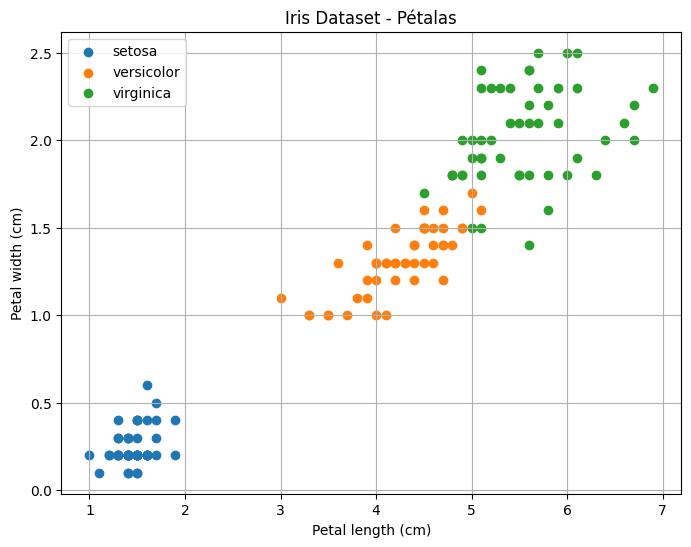

In [24]:
# Petal length vs petal width

plt.figure(figsize=(8, 6))
for i, target_name in enumerate(target_names):
    plt.scatter(X[y == i, 2], X[y == i, 3], label=target_name)

plt.xlabel('Petal length (cm)')
plt.ylabel('Petal width (cm)')
plt.title('Iris Dataset - Pétalas')
plt.legend()
plt.grid(True)
plt.show()

---

### Testando o algoritmo

In [25]:
# Instanciando o modelo e definindo o k

knn = KNeighborsClassifier(n_neighbors=3,metric='euclidean') # por padrão já é a distância euclidiana, mas mantive aqui para a visualização~

In [26]:
# Treinando o modelo = apenas armazenando os dados separados como treino

knn.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=3)

In [27]:
# Previsões

y_pred = knn.predict(X_test)

* precision ➜ Entre as flores que o modelo previu como sendo da classe X, quantas ele acertou?  
* recall ➜ Entre as flores que de fato são da classe X, quantas o modelo acertou?  
* f1-score ➜ Média harmônica entre precision e recall (equilíbrio entre eles)  
* support ➜ Quantas amostras reais havia dessa classe no conjunto de teste

In [28]:
# Métricas

print(classification_report(y_test, y_pred, target_names=load_iris().target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



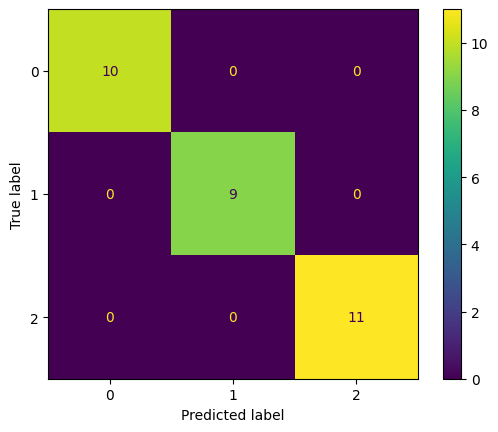

In [29]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)
disp.plot()
plt.show()

* Classe 0: 10 acertos

* Classe 1: 9 acertos

* Classe 2: 11 acertos

* Fora da diagonal: Todos os valores são 0, ou seja, não há erros de classificação